In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [19]:
df = pd.read_csv("./Country-data.csv")

## 1. Understanding the dataset

In [3]:
df.shape

(167, 10)

In [4]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

In [5]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [10]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## 2. Outlier analysis

In [20]:
dfcopy = df.drop("country", axis=1)

dfcopy.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


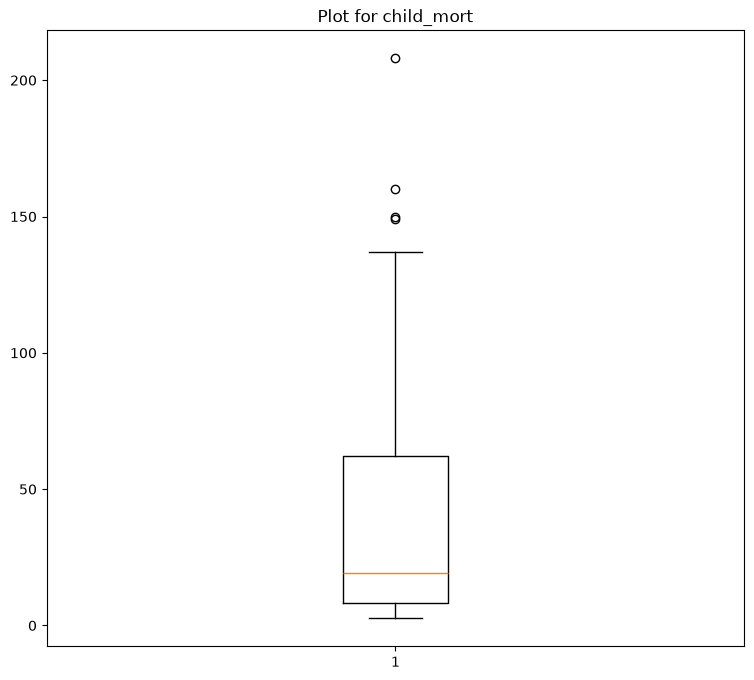

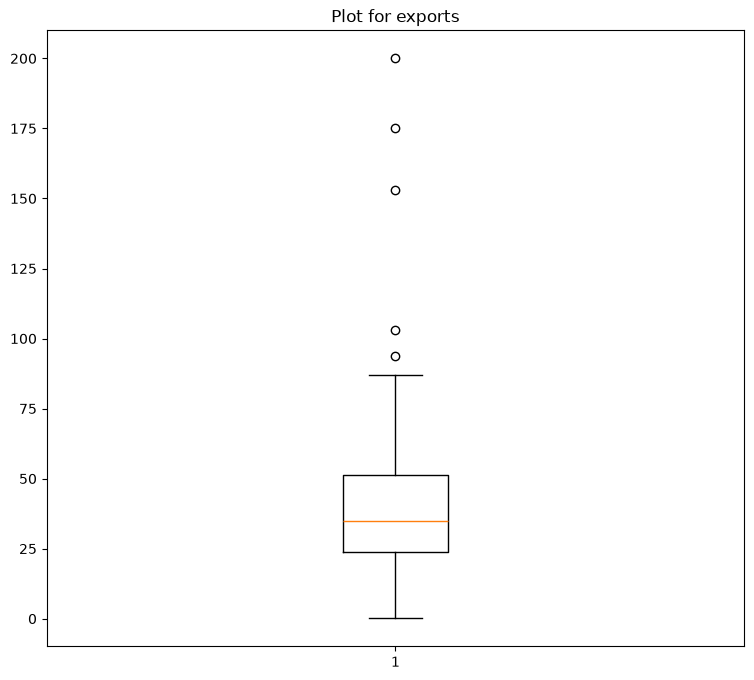

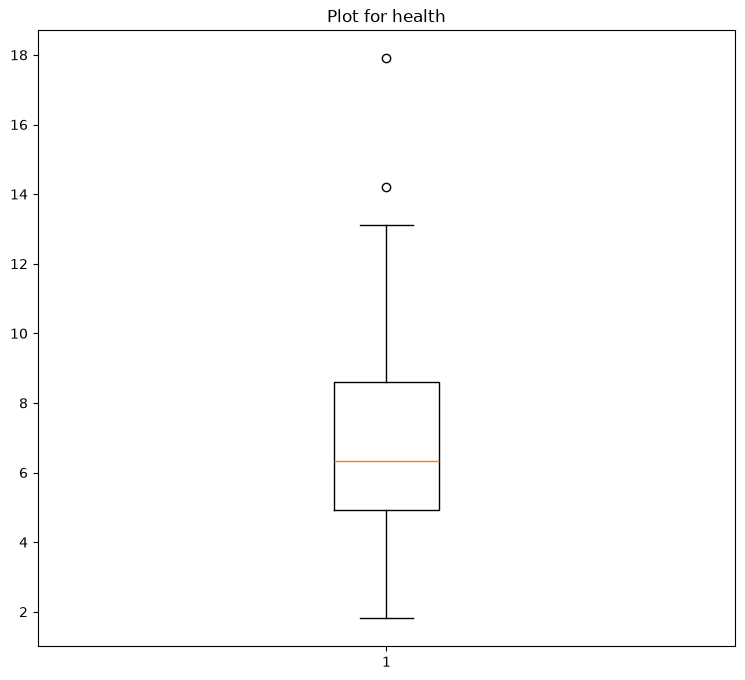

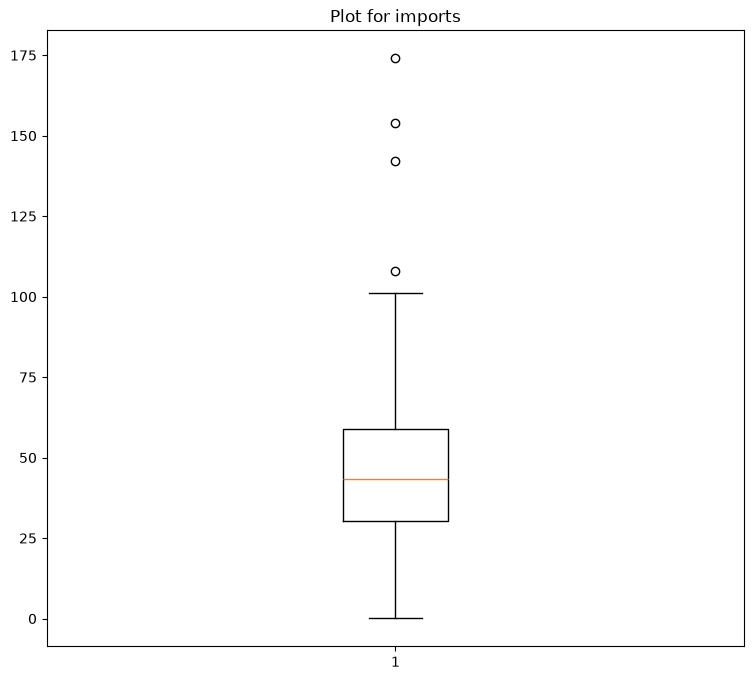

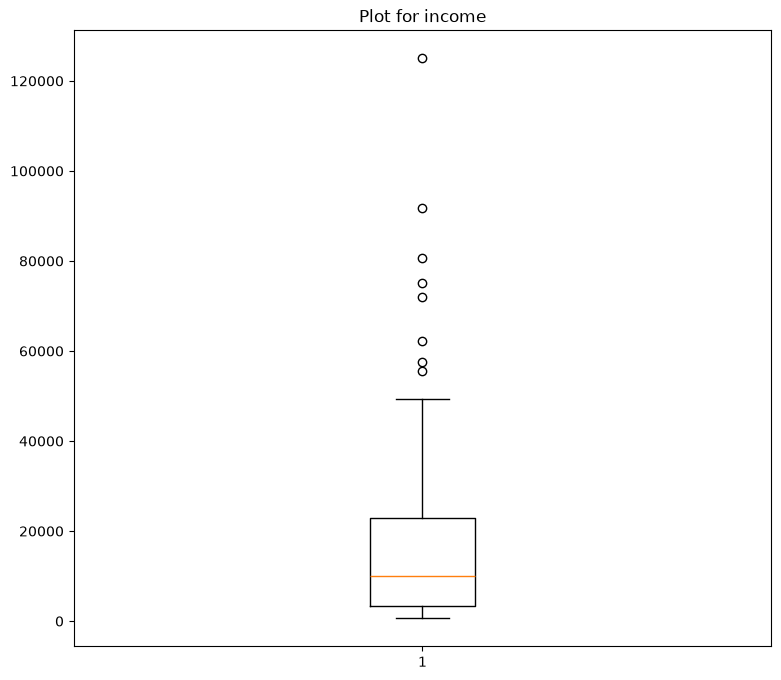

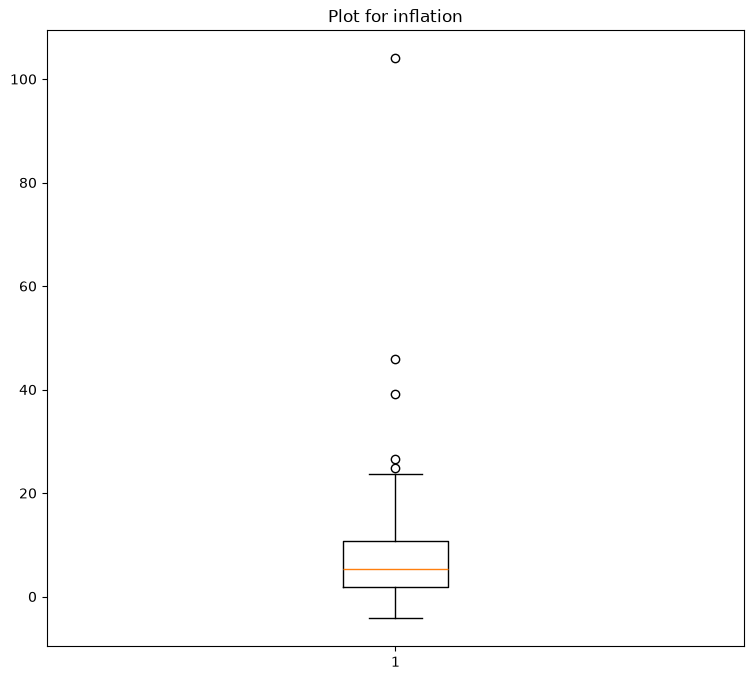

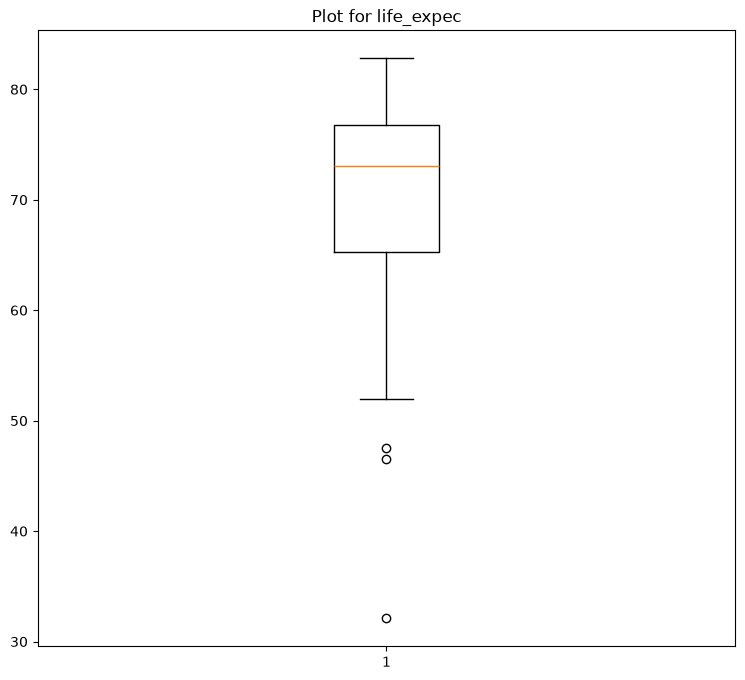

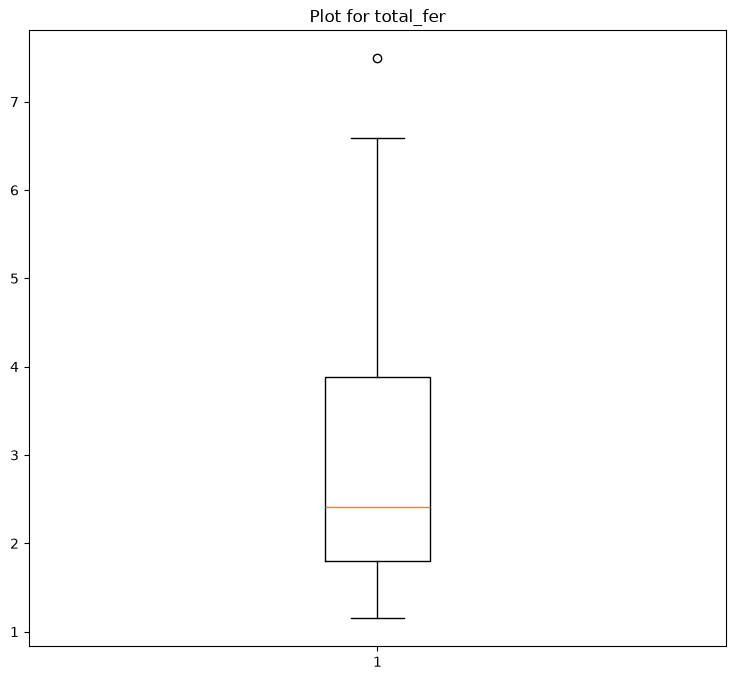

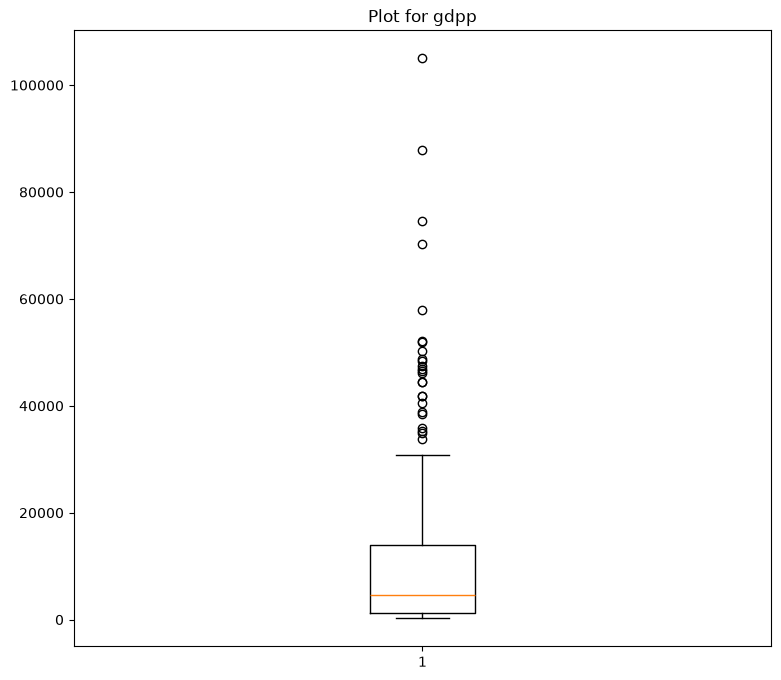

In [21]:
for col in dfcopy.columns:
    plt.figure(figsize=(9,8))
    plt.boxplot(x=dfcopy[col])
    plt.title(f"Plot for {col}")
    plt.show()

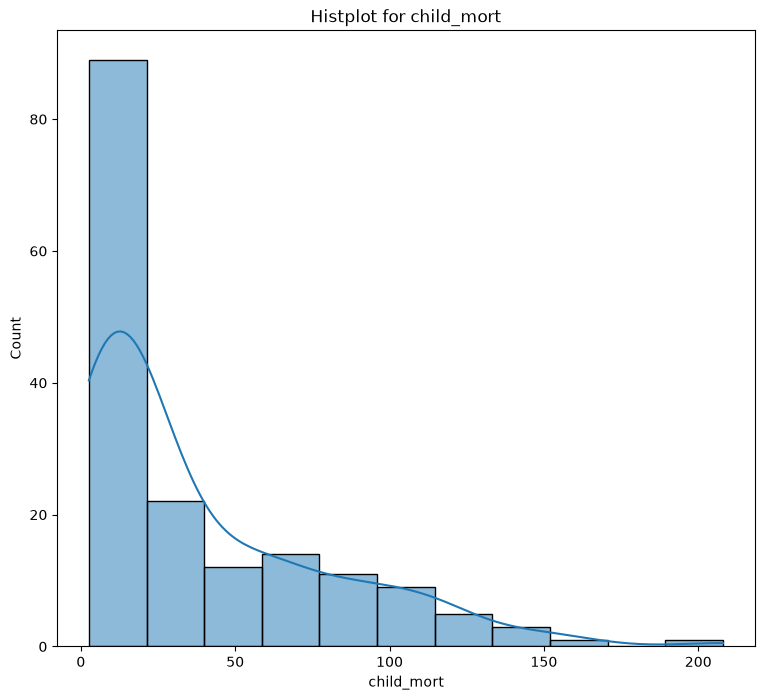

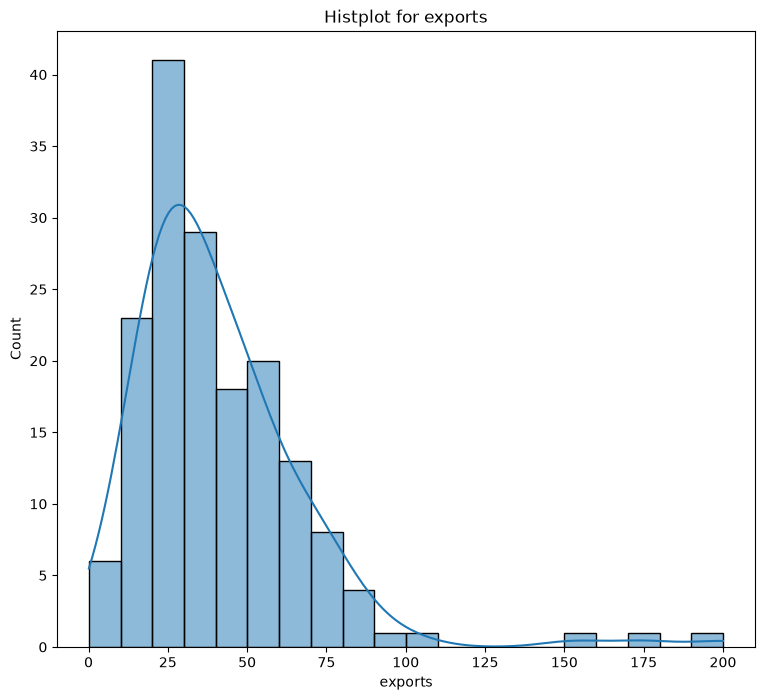

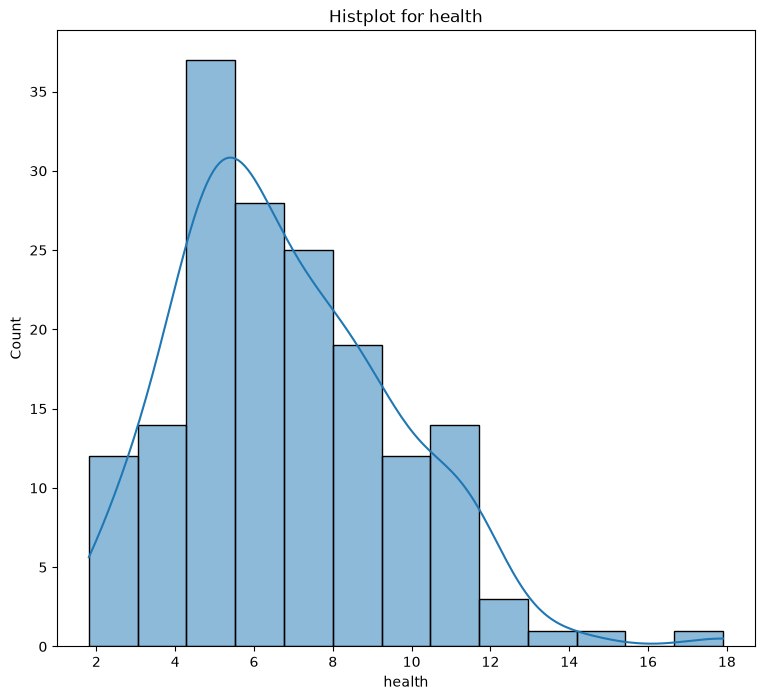

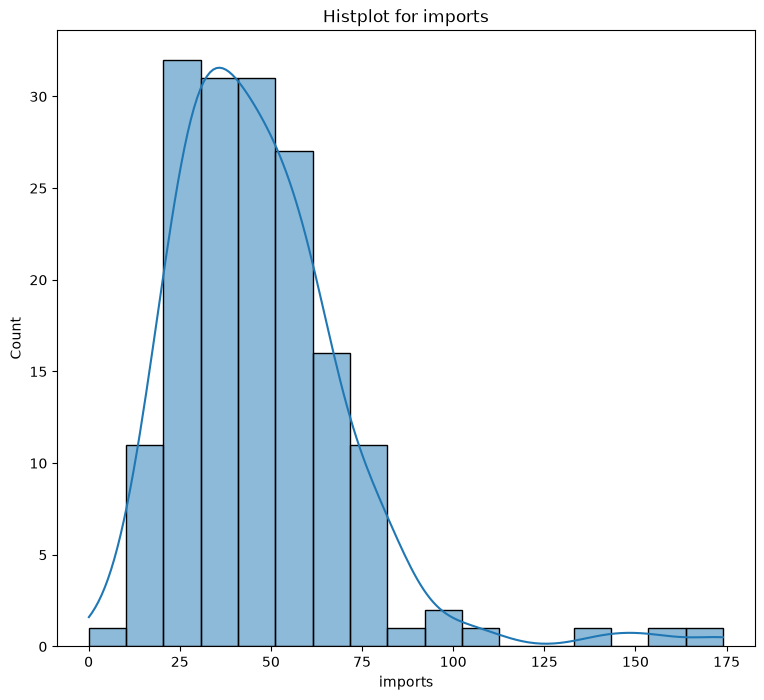

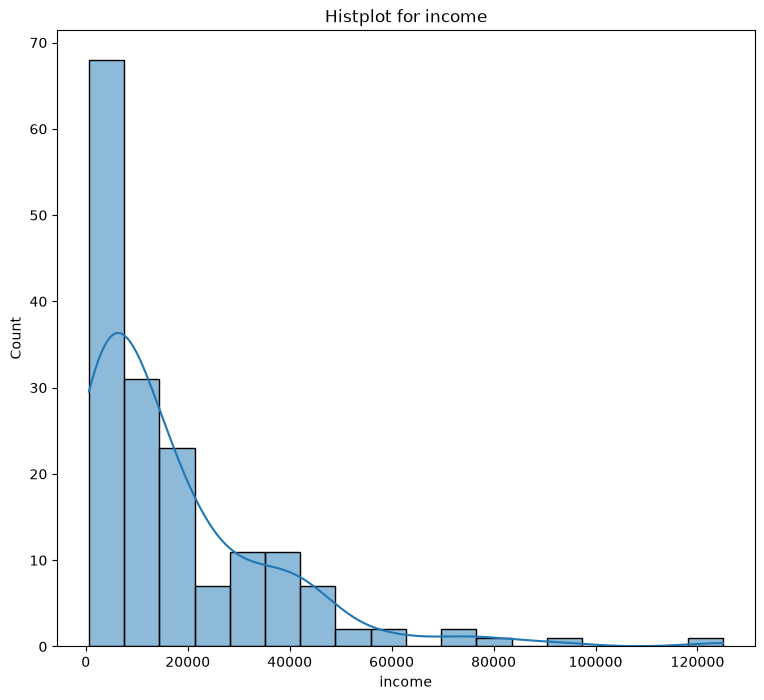

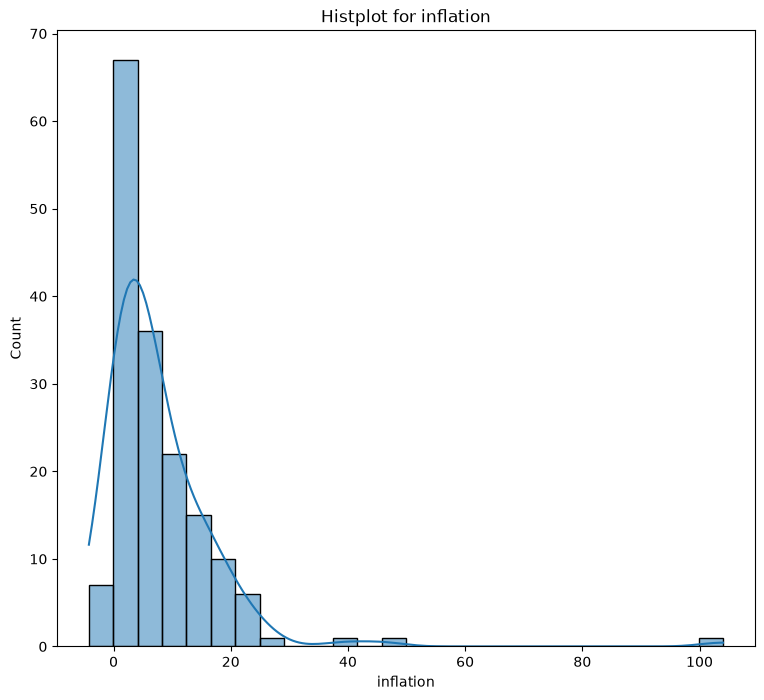

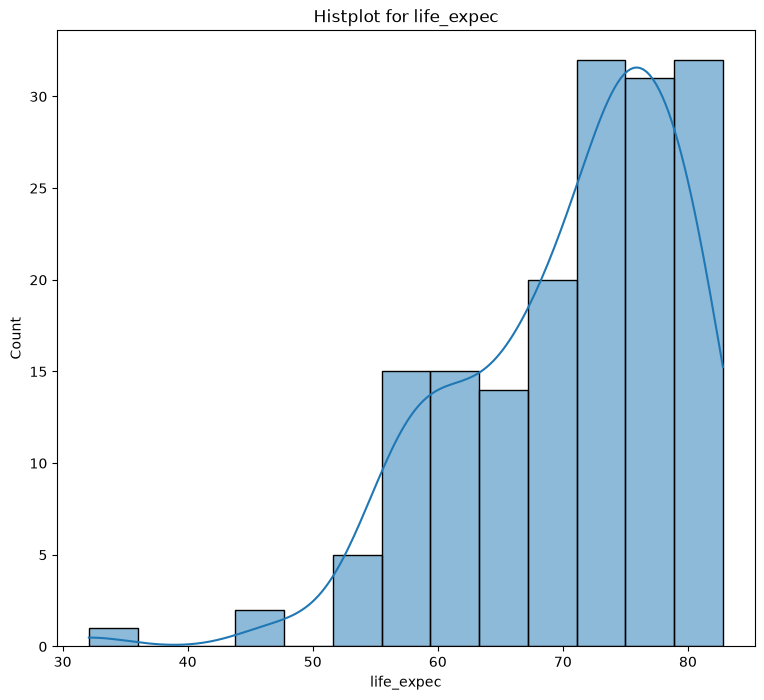

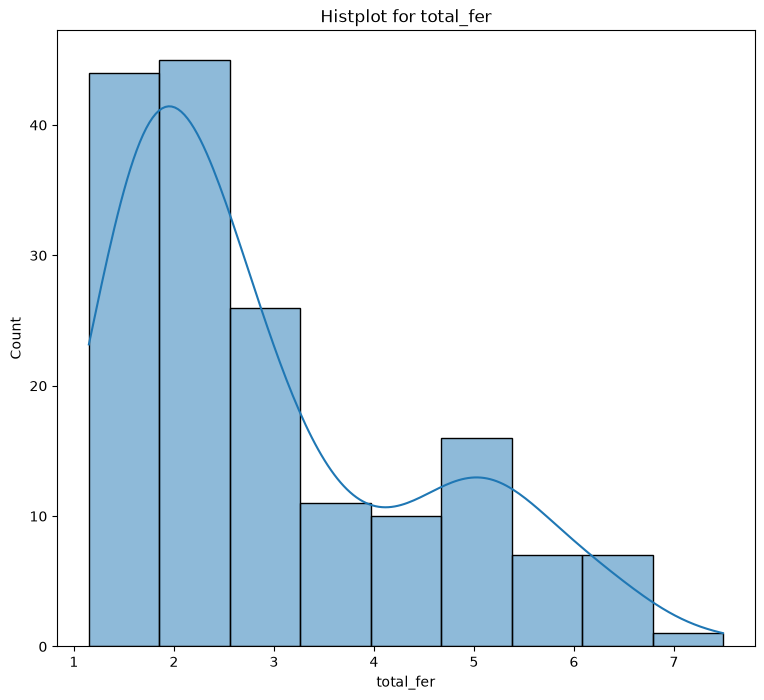

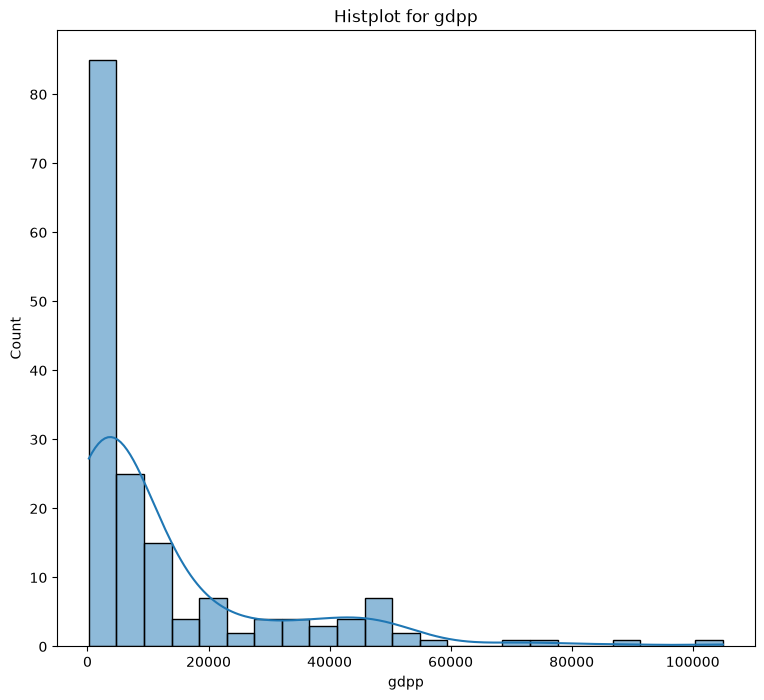

In [23]:
for col in dfcopy.columns:
    plt.figure(figsize=(9,8))
    sns.histplot(dfcopy[col], kde=True)
    plt.title(f"Histplot for {col}")
    plt.show()

IQR method for deeper analysis

In [32]:
dfcopy.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

In [34]:
iqr_counts = {}

for col in dfcopy.columns:
    Q1 = dfcopy[col].quantile(0.25)
    Q3 = dfcopy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    iqr_counts[col] = int(((dfcopy[col] < lower_limit) | (dfcopy[col] > upper_limit)).sum())

pd.DataFrame({ "IQR outliers ": iqr_counts })

,IQR outliers
child_mort,4
exports,5
health,2
imports,4
income,8
inflation,5
life_expec,3
total_fer,1
gdpp,25


Logically this outliers are not of much problem

## 3. Correlation analysis

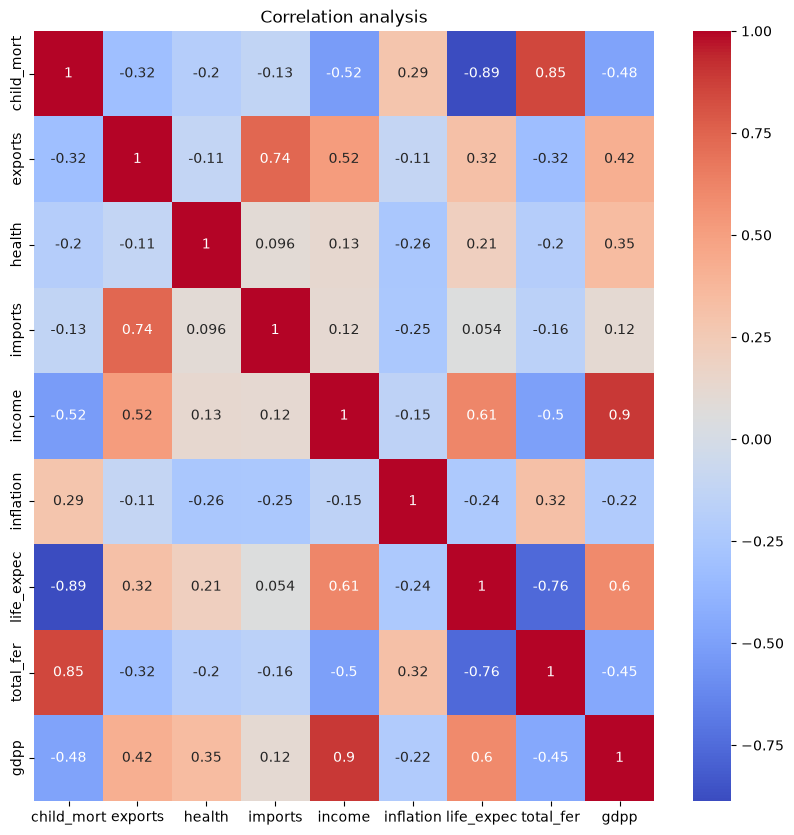

In [36]:
corr = dfcopy.select_dtypes(include='number').corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation analysis")
plt.show()

#### Strong positive relation exist among the columns:
- gdpp and income
- total fer and child mort
- import and export

#### Strong negative relation exist among the columns:
- total fer and life expaec
- life expec and child mort

## 4. Feature scaling

In [37]:
scalar = StandardScaler()

scaled_data = scalar.fit_transform(dfcopy)

scaled_df = pd.DataFrame(scaled_data, columns=dfcopy.columns)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [38]:
scaled_df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,-3.722904e-17,2.127373e-16,5.504579e-16,2.765585e-16,-7.977650e-17,-1.063687e-17,3.696311e-16,3.044803e-16,5.850277e-17
std,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00
min,-8.871383e-01,-1.500192e+00,-1.827827e+00,-1.939940e+00,-8.603259e-01,-1.137852e+00,-4.337186e+00,-1.191250e+00,-6.968005e-01
25%,-7.466190e-01,-6.333367e-01,-6.922106e-01,-6.914785e-01,-7.174558e-01,-5.666409e-01,-5.927576e-01,-7.639023e-01,-6.366596e-01
50%,-4.717981e-01,-2.235279e-01,-1.810007e-01,-1.487432e-01,-3.738080e-01,-2.269504e-01,2.869576e-01,-3.564309e-01,-4.544309e-01
75%,5.926666e-01,3.747198e-01,6.515412e-01,4.913530e-01,2.942370e-01,2.816364e-01,7.042584e-01,6.175252e-01,5.942100e-02
max,4.221297e+00,5.813835e+00,4.047436e+00,5.266181e+00,5.611542e+00,9.129718e+00,1.380962e+00,3.009349e+00,5.036507e+00


## 5. Using Elbow method to find the suitable values of k

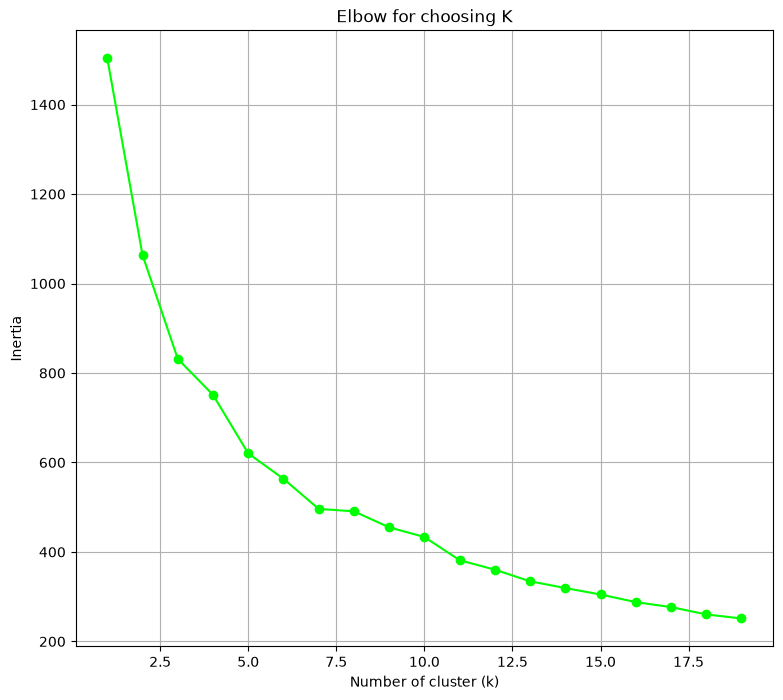

In [40]:
inertia_values = []

for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(9,8))
plt.plot(range(1, 20), inertia_values, marker="o", color="lime")
plt.title("Elbow for choosing K")
plt.xlabel("Number of cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

## 6. Using Silhouette score to find possible K values 

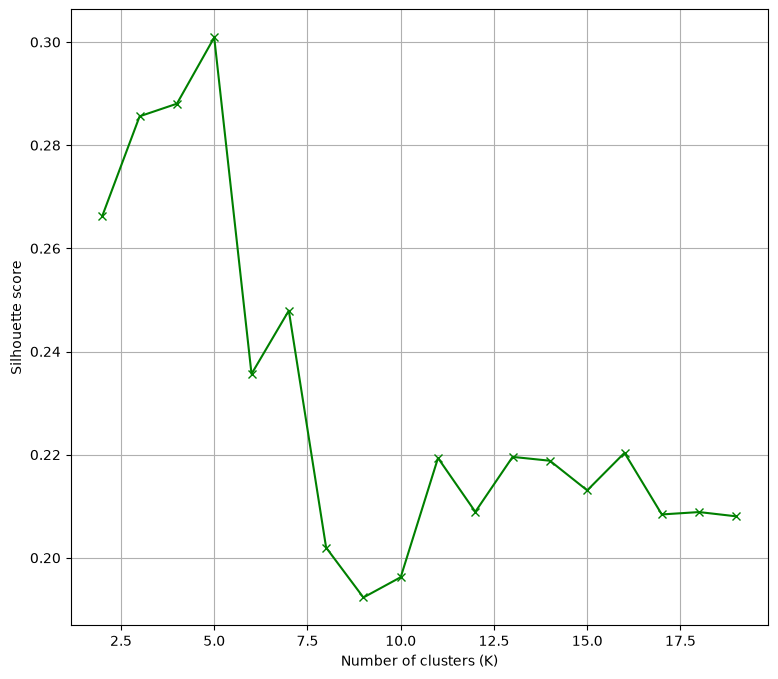

In [41]:
silhouette_scores = []

for k in range(2 ,20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(9,8))
plt.plot(range(2, 20), silhouette_scores, marker="x", color="green")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

Choosing K = 4 based on the elbow and the silhouette score

## 7. Applying the K means clustering for K = 4

In [48]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(scaled_df)

dfcopy["Cluster"] = kmeans.labels_
dfcopy.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [49]:
dfcopy["Cluster"].value_counts()

Cluster
0    86
2    44
1    36
3     1
Name: count, dtype: int64

## 8. PCA Visualization

Before Clustering

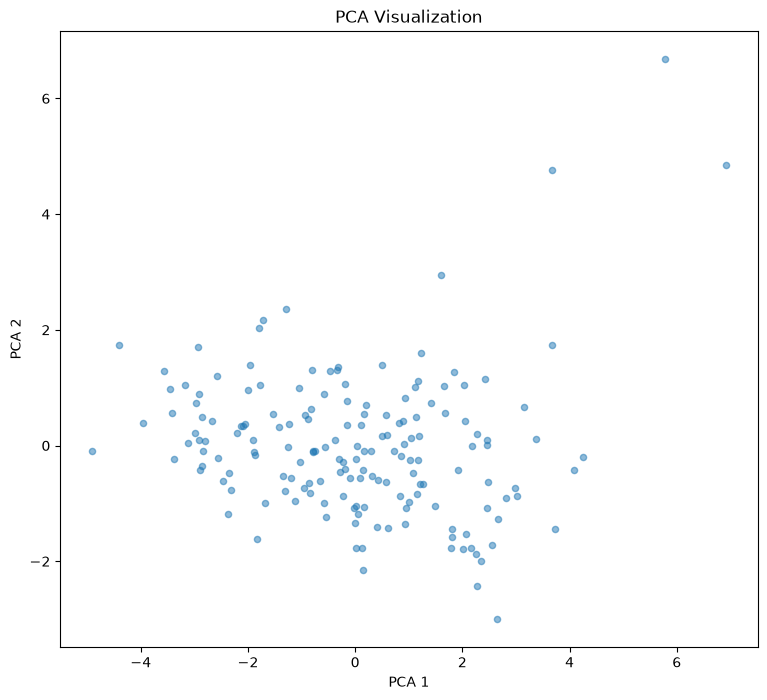

In [50]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(9,8))
plt.scatter(pca_components[:, 0], pca_components[:, 1], s=20, alpha=0.5)
plt.title("PCA Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

After Clustering

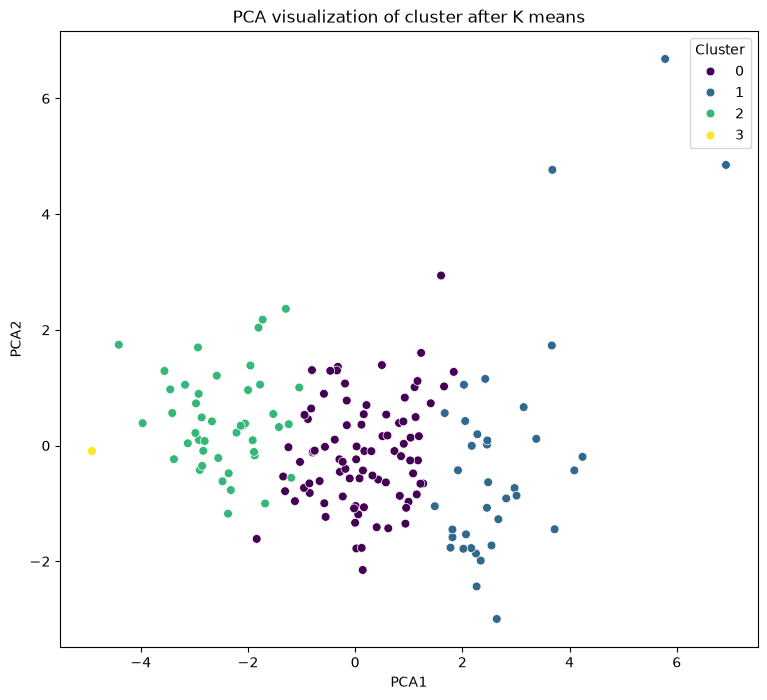

In [52]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(data=pca_components, columns=["PCA1", "PCA2"])
pca_df["Cluster"] = dfcopy["Cluster"]

plt.figure(figsize=(9,8))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", palette="viridis", data=pca_df, s=40)
plt.title("PCA visualization of cluster after K means")
plt.show()

## 9. Cluster interpretation

In [53]:
cluster_profile = dfcopy.groupby("Cluster").mean()

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,94.313636,28.677500,6.329091,42.872727,3503.250000,9.895568,59.022727,5.047727,1753.909091
3,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000


- Cluster 0 = Highly developing countries / Safe to live countries (Higher than average export, import, life expec and gddp)
- Cluster 1 = Developed countries / Best countries to live in (Lowest child mortality, inflation, total fertility and highest export, health, import, income, life expectancy and gdpp.)
- Cluster 2 = Slowly developing countries / Under developed / Not a good choice for living (Lowest GDPP, life expectancy, income, heavy import dependent, higher than average child mort, health, inflation, total fertility)
- Cluster 3 = Backward countries / Highly underdeveloped / Worst choice of living (Highest child mortality, inflation and total fertility. Lowest export, import, health)

## 10. Visualization

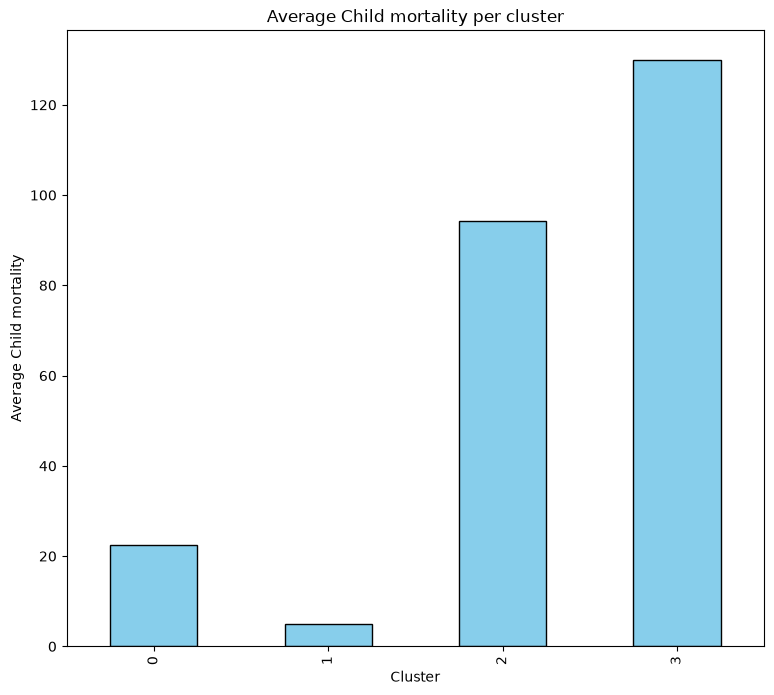

In [54]:
plt.figure(figsize=(9,8))
cluster_profile["child_mort"].plot(kind="bar", color='skyblue', edgecolor="#010101")
plt.title("Average Child mortality per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Child mortality")
plt.show()

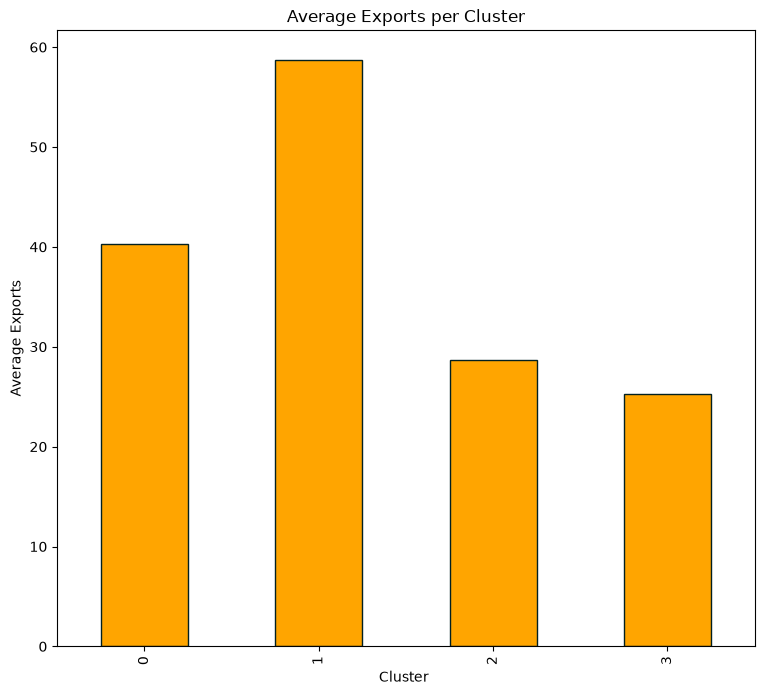

In [55]:
plt.figure(figsize=(9,8))
cluster_profile["exports"].plot(kind="bar", color="orange", edgecolor="#022020")
plt.title("Average Exports per Cluster")
plt.xlabel("Cluster ")
plt.ylabel("Average Exports")
plt.show()

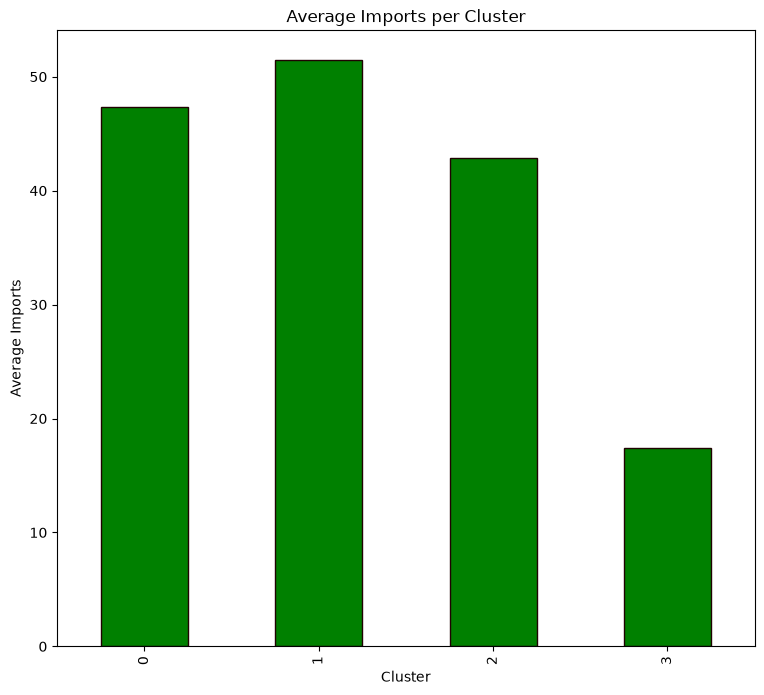

In [56]:
plt.figure(figsize=(9,8))
cluster_profile["imports"].plot(kind="bar", color="green", edgecolor="#200202")
plt.title("Average Imports per Cluster")
plt.xlabel('Cluster')
plt.ylabel("Average Imports")
plt.show()

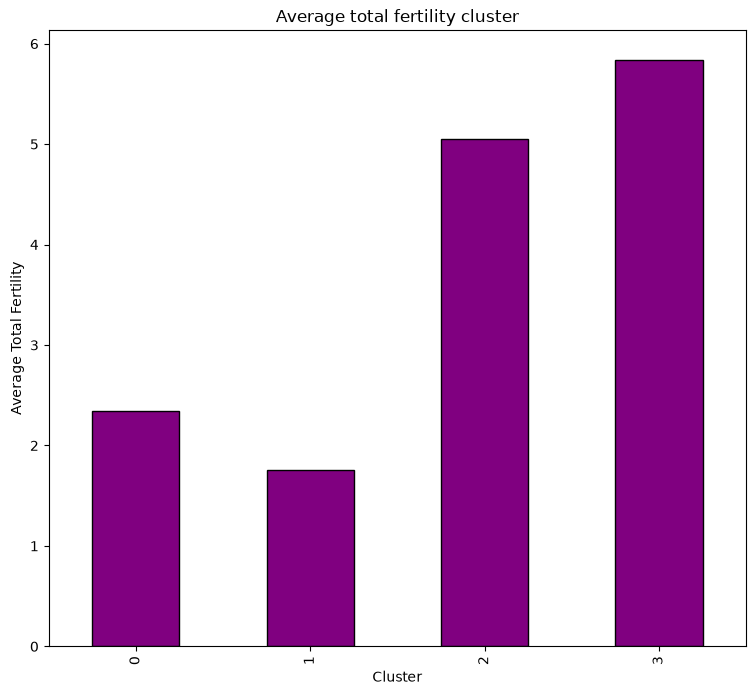

In [57]:
plt.figure(figsize=(9,8))
cluster_profile["total_fer"].plot(kind="bar", color="purple", edgecolor="#010101")
plt.title("Average total fertility cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Fertility")
plt.show()

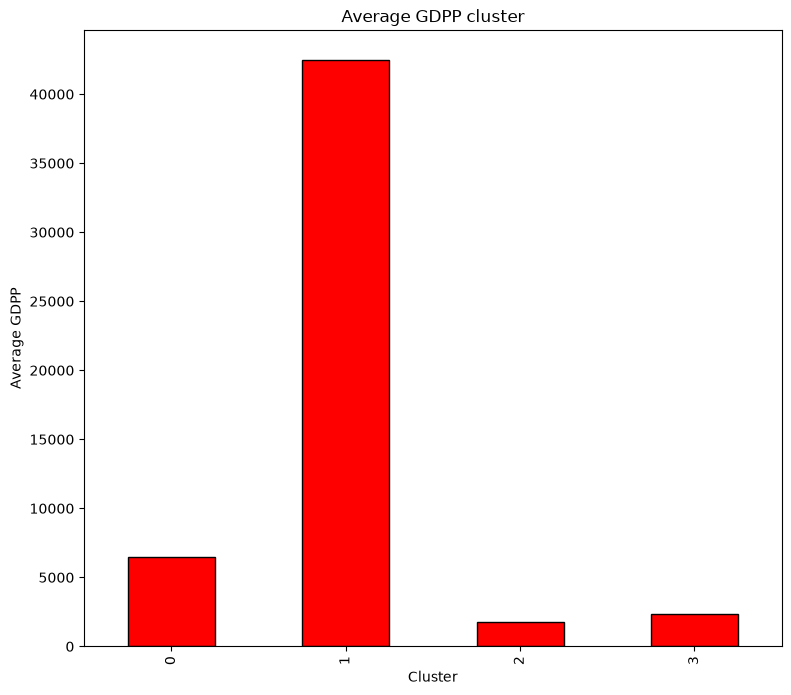

In [58]:
plt.figure(figsize=(9,8))
cluster_profile["gdpp"].plot(kind="bar", color="red", edgecolor="#030303")
plt.title("Average GDPP cluster")
plt.xlabel("Cluster")
plt.ylabel("Average GDPP")
plt.show()

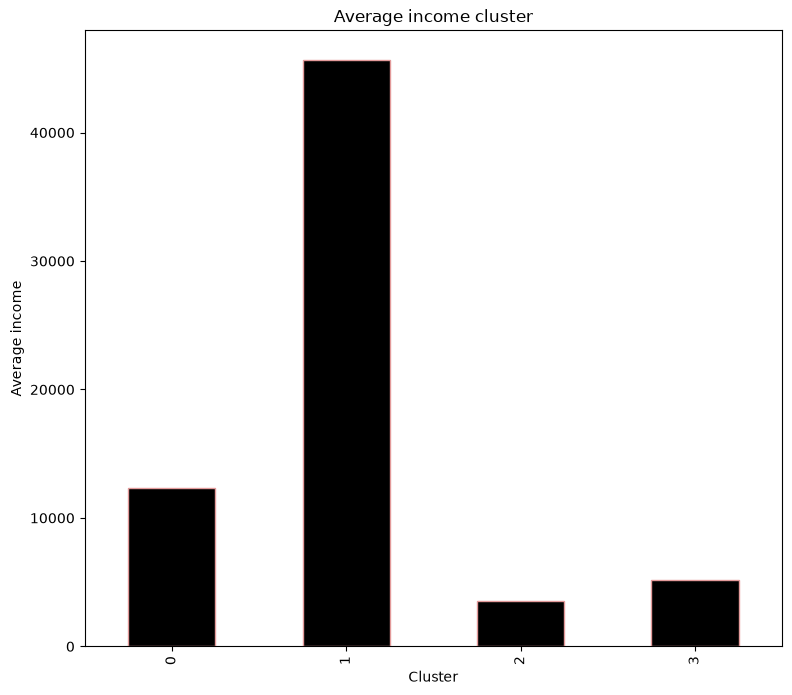

In [ ]:
plt.figure(figsize=(9,8))
cluster_profile["income"].plot(kind="bar", color="black", edgecolor="#FF0000")
plt.title("Average income cluster")
plt.xlabel("Cluster")
plt.ylabel("Average income")
plt.show()

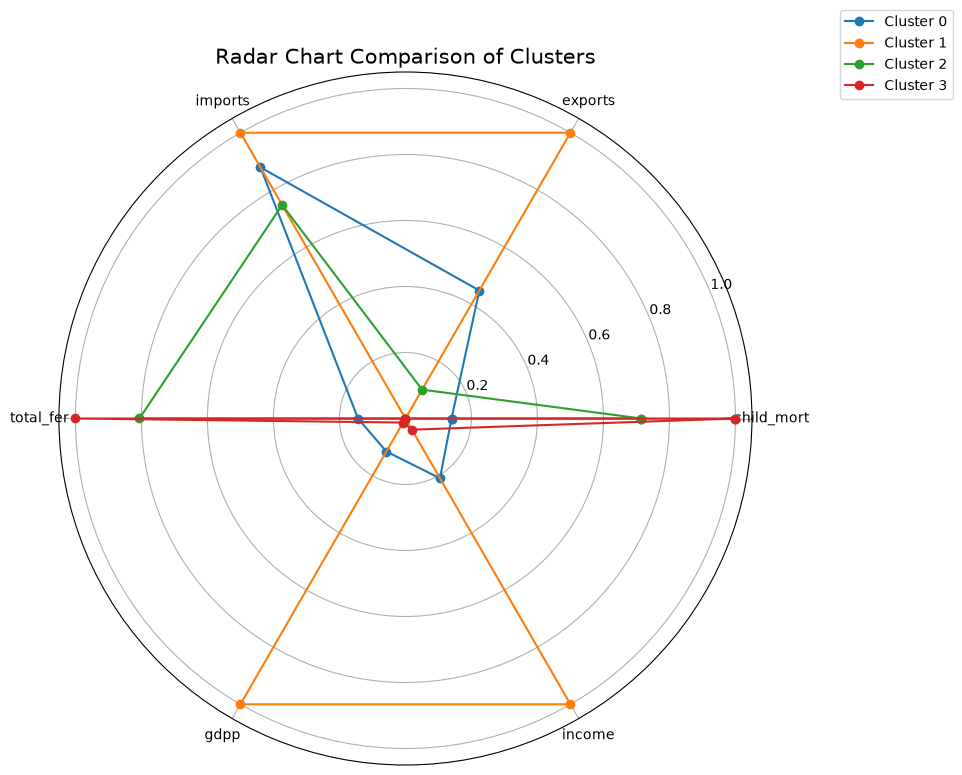

In [59]:
features = ['child_mort', 'exports', 'imports', 'total_fer', 'gdpp', 'income']
    
data = cluster_profile[features]

data_norm = (data - data.min()) / (data.max() - data.min())

num_vars = len(features)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(9, 9))

for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]

    plt.polar(angles, values, marker='o', label=f'Cluster {i}')

plt.xticks(angles[:-1], features)
plt.title("Radar Chart Comparison of Clusters", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()